<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_058_brier_score_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 58/365 — Brier Score
## How do we measure whether predicted probabilities are actually good?

Yesterday we explored **Probability Calibration**.

Today we need a metric that evaluates probability quality directly:

**Brier Score**

For binary classification:

`Brier Score = mean((predicted_probability - actual_outcome)^2)`

Lower is better.

A perfect probability forecast gets:

`Brier Score = 0`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss


## 1. Tiny manual example


In [2]:
actual=np.array([1,0,1])
probs=np.array([0.9,0.4,0.6])

manual_brier=np.mean((probs-actual)**2)

print("Manual Brier Score:",round(manual_brier,4))


Manual Brier Score: 0.11


## 2. Why confidence matters

Two models can make the same class prediction but assign very different probabilities.

Brier Score evaluates how close those probabilities are to the actual 0/1 outcomes.


## 3. Load a real dataset


In [3]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

print("Dataset shape:",X.shape)


Dataset shape: (569, 30)


## 4. Train Logistic Regression and Random Forest


In [4]:
log_reg=LogisticRegression(max_iter=5000)
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train,y_train)
rf.fit(X_train,y_train)

log_prob=log_reg.predict_proba(X_test)[:,1]
rf_prob=rf.predict_proba(X_test)[:,1]


## 5. Compare Accuracy, Log Loss and Brier Score


In [5]:
comparison=pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,(log_prob>=0.5).astype(int)),
        accuracy_score(y_test,(rf_prob>=0.5).astype(int))
    ],
    "Log Loss":[
        log_loss(y_test,log_prob),
        log_loss(y_test,rf_prob)
    ],
    "Brier Score":[
        brier_score_loss(y_test,log_prob),
        brier_score_loss(y_test,rf_prob)
    ]
})

display(comparison.round(4))


,Model,Accuracy,Log Loss,Brier Score
0,Logistic Regression,0.958,0.0872,0.0280
1,Random Forest,0.958,0.1046,0.0296


## 6. Calibrate the Random Forest


In [6]:
calibrated_rf=CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    method="isotonic",
    cv=5
)

calibrated_rf.fit(X_train,y_train)
cal_rf_prob=calibrated_rf.predict_proba(X_test)[:,1]

calibrated_results=pd.DataFrame({
    "Model":["Random Forest","Calibrated Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,(rf_prob>=0.5).astype(int)),
        accuracy_score(y_test,(cal_rf_prob>=0.5).astype(int))
    ],
    "Log Loss":[
        log_loss(y_test,rf_prob),
        log_loss(y_test,cal_rf_prob)
    ],
    "Brier Score":[
        brier_score_loss(y_test,rf_prob),
        brier_score_loss(y_test,cal_rf_prob)
    ]
})

display(calibrated_results.round(4))


,Model,Accuracy,Log Loss,Brier Score
0,Random Forest,0.958,0.1046,0.0296
1,Calibrated Random Forest,0.958,0.1111,0.0330


## 7. Visual — Brier Score before vs after calibration


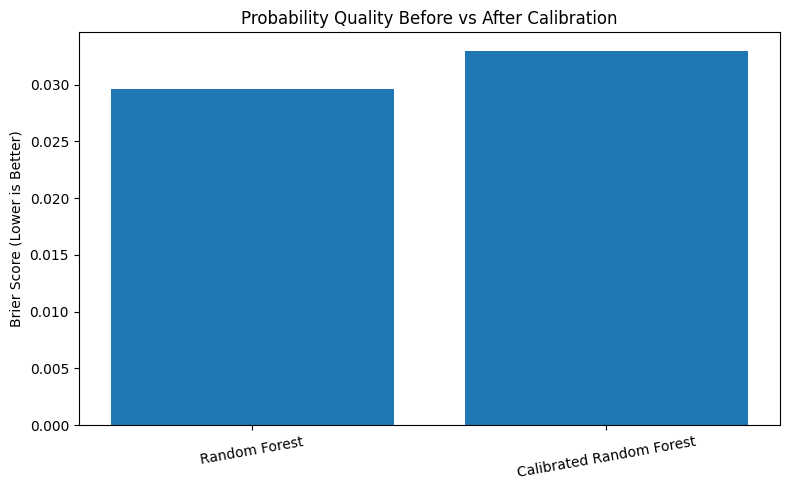

In [7]:
plt.figure(figsize=(8,5))
plt.bar(
    calibrated_results["Model"],
    calibrated_results["Brier Score"]
)
plt.ylabel("Brier Score (Lower is Better)")
plt.title("Probability Quality Before vs After Calibration")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 8. Calibration curve + Brier Score


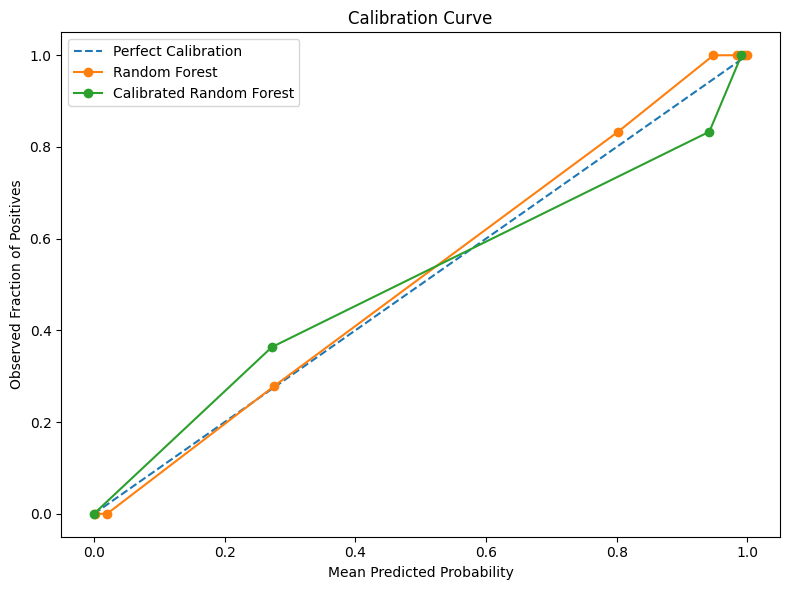

In [8]:
rf_true,rf_pred=calibration_curve(
    y_test,rf_prob,n_bins=8,strategy="quantile"
)

cal_true,cal_pred=calibration_curve(
    y_test,cal_rf_prob,n_bins=8,strategy="quantile"
)

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],linestyle="--",label="Perfect Calibration")
plt.plot(rf_pred,rf_true,marker="o",label="Random Forest")
plt.plot(cal_pred,cal_true,marker="o",label="Calibrated Random Forest")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()


## Enterprise intuition

Imagine a credit-risk model.

Two customers are both classified as high risk:

- Customer A: default probability = 0.52
- Customer B: default probability = 0.95

Those numbers may drive very different actions.

If probabilities are used for:

- risk-based pricing
- fraud-review priority
- credit limits
- capital allocation
- claims triage

then probability quality matters.

Brier Score gives us a direct way to evaluate that quality.


## Important nuance

Brier Score reflects overall probabilistic accuracy, not calibration alone.

So a lower Brier Score means the probability forecasts are closer to the observed outcomes overall.


## What does this teach?

- Accuracy evaluates class decisions.
- Brier Score evaluates the probabilities themselves.
- Lower Brier Score is better.
- Similar accuracy does not imply similar probability quality.
- Calibration may improve Brier Score without changing accuracy much.
- Calibration curves and Brier Score complement each other.

> **If probabilities drive business decisions, evaluating only accuracy is not enough.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html
- https://scikit-learn.org/stable/modules/calibration.html
- https://doi.org/10.1175/1520-0493(1950)078%3C0001:VOFEIT%3E2.0.CO;2
- https://dl.acm.org/doi/10.1145/1102351.1102430
